# 06. 다중 객체 추적 (Phase 7) — 칼만 필터를 실제 데이터로 뜯어보기

**목표**: Phase 6 융합 결과(`outputs/phase6/objects_clustered.json`)를 프레임 0~60 동안 `KalmanTracker.step` 으로 **직접** 돌리면서,
예측/갱신에서 상태와 공분산이 어떻게 변하는지, 비용 행렬과 게이트가 어떻게 매칭을 정하는지, 트랙이 언제 태어나고 확정되고 죽는지를 숫자와 그림으로 확인한다.
마지막에 Phase 8 평가 함수(`evaluate_variant`)로 파라미터 스윕을 해 IDSW·재현율이 어떻게 달라지는지 본다.

| 질문 | 답 |
|---|---|
| 입력은? | 프레임마다 `list[Object3D]` (Velodyne, m). `status == "ok"` 이고 `center` (3,) 가 있는 것만 관측 z 로 쓴다 |
| 출력은? | `list[Track]` (confirmed 만). `state` (6,) = [x, y, z, vx, vy, vz], `covariance` (6, 6) |
| 좌표계는? | Velodyne (x 전방, y 좌, z 상). **자차에 고정된 프레임**이므로 속도는 자차 기준 상대속도 |
| 핵심 알고리즘은? | 등속 칼만 필터 (예측 → 갱신) + 마할라노비스 게이트 + 헝가리안 할당 + 생명주기 (tentative → confirmed → deleted) |
| 실패 사례는? | 먼 물체의 검출 깜빡임 → 트랙 사망·재생성 → ID 스위치. coasting 중 드리프트 → 유령 FP |
| 평가는? | tracklet GT 와 BEV 2 m 매칭: IDSW, 단절, MT/PT/ML, 재현율·정밀도 (`evaluation/evaluate.py`, Phase 8) |

용어
- **예측(predict)**: 이전 상태에서 dt 만큼 등속으로 밀어 본 값. 불확실성(공분산 P)은 커진다.
- **갱신(update)**: 관측 z 로 예측을 보정. P 는 작아진다. 혁신(innovation) y = z − Hx⁻ 가 "예측이 얼마나 틀렸나".
- **마할라노비스 거리** d² = yᵀ S⁻¹ y: 혁신을 그 불확실성 S 로 나눈 거리. 같은 1 m 오차라도 P 가 크면(불확실하면) d² 는 작다.
- **게이트(gate)**: d² 가 임계값(9.21 = χ² 3 자유도 97.5 %) 을 넘으면 매칭 후보에서 제외.
- **coasting**: 관측이 없어도 예측만으로 트랙을 유지하는 상태 (misses > 0).

In [1]:
import copy, json, collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from perceptrack3d.config import load_config
from perceptrack3d.data.kitti_loader import KittiDataset
from perceptrack3d.geometry.calibration import KittiCalibration
from perceptrack3d.fusion.frustum_fusion import load_objects_json
from perceptrack3d.tracking.kalman_tracker import KalmanTracker, KalmanFilterCV
from perceptrack3d.tracking.association import build_cost_matrix, hungarian_assign
from perceptrack3d.evaluation.tracklets import gt_boxes_by_frame, gt_in_front_fov, box_corners_bev
from perceptrack3d.evaluation.evaluate import evaluate_variant, select_gt
from perceptrack3d.visualization.track_frames import draw_tracks_on_image
from perceptrack3d.types import Track

%matplotlib inline
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.width", 160)

cfg = load_config()
ds = KittiDataset(cfg)
calib = KittiCalibration.from_dir(cfg["dataset"]["calib_dir"])
objects = load_objects_json(f"{cfg['outputs']['dir']}/phase6/objects_clustered.json")   # {frame_id: [Object3D]}
gts = gt_boxes_by_frame(cfg["dataset"]["tracklets"])                                     # {frame_id: [GtBox3D]}
FRAMES = list(range(0, 61))
tcfg = cfg["tracking"]
print("tracking 설정:", {k: tcfg[k] for k in ("dt", "gating", "gate_mahalanobis", "max_misses", "min_hits", "process_noise_pos", "process_noise_vel", "measurement_noise", "initial_vel_std")})
n_obs = [sum(o.status == "ok" for o in objects[f]) for f in FRAMES]
print(f"프레임 0~60: 융합 객체 {sum(len(objects[f]) for f in FRAMES)}개 중 status ok = {sum(n_obs)} (프레임당 {np.mean(n_obs):.1f}개), GT(FOV 안) 프레임당 {np.mean([len(gt_in_front_fov(gts[f])) for f in FRAMES]):.1f}개")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


tracking 설정: {'dt': 0.1, 'gating': 'mahalanobis', 'gate_mahalanobis': 9.21, 'max_misses': 3, 'min_hits': 3, 'process_noise_pos': 0.5, 'process_noise_vel': 1.0, 'measurement_noise': 0.5, 'initial_vel_std': 10.0}
프레임 0~60: 융합 객체 258개 중 status ok = 193 (프레임당 3.2개), GT(FOV 안) 프레임당 3.7개


## 6.1 칼만 필터 한 사이클을 손으로 돌려 보기

`KalmanFilterCV` 는 상태를 갖지 않는 순수 함수 모음이다. 행렬 모양부터 확인한다.

```
x = [px, py, pz, vx, vy, vz]     (6,)      F (6,6) 상태 전이   H (3,6) 관측 (위치만)
Q (6,6) 프로세스 잡음   R (3,3) 관측 잡음   P (6,6) 상태 공분산
```
프레임 0 의 첫 관측으로 트랙을 만들고(init) → 프레임 1 로 예측(predict) → 프레임 1 의 실제 관측으로 갱신(update).
**공분산 대각 = 각 상태의 분산(σ²)**. 예측 후 커지고 갱신 후 작아지는 것을 본다. 속도 분산은 첫 갱신에서 크게 줄어드는데, 위치 두 개를 알면 속도가 결정되기 때문이다.

In [2]:
kf = KalmanFilterCV(tcfg["dt"], tcfg["process_noise_pos"], tcfg["process_noise_vel"], tcfg["measurement_noise"], tcfg["initial_vel_std"])
print("F =\n", kf.F, "\nH =\n", kf.H, "\nQ diag =", np.diag(kf.Q), "\nR diag =", np.diag(kf.R))

obs0 = [o for o in objects[0] if o.status == "ok"]
obs1 = [o for o in objects[1] if o.status == "ok"]
z0 = obs0[1].center                       # 프레임 0 의 두 번째 검출 (앞차, x≈35 m)
z1 = min((o.center for o in obs1), key=lambda c: np.linalg.norm(c - z0))   # 프레임 1 에서 가장 가까운 관측
np.set_printoptions(precision=3, suppress=True)
x, P = kf.init_state(z0)
print(f"\n[init]    z0 = {z0}\n          x = {x}\n          P diag = {np.diag(P)}   (위치 σ²=R, 속도 σ²=initial_vel_std²)")
xp, Pp = kf.predict(x, P)
print(f"[predict] x⁻ = {xp}   (속도 0 이라 위치 그대로)\n          P⁻ diag = {np.diag(Pp)}   (위치 분산 += dt²·σv² + σp² = {tcfg['dt']**2 * tcfg['initial_vel_std']**2 + tcfg['process_noise_pos']**2:.2f})")
S = kf.innovation_covariance(Pp); y = z1 - kf.H @ xp
print(f"          S = H P⁻ Hᵀ + R diag = {np.diag(S)},  혁신 y = z1 − Hx⁻ = {y},  d² = {y @ np.linalg.inv(S) @ y:.3f}  (게이트 {tcfg['gate_mahalanobis']})")
xu, Pu = kf.update(xp, Pp, z1)
K = Pp @ kf.H.T @ np.linalg.inv(S)
print(f"[update]  z1 = {z1}\n          x = {xu}   → 속도 추정 {xu[3:]} m/s (= 혁신 × 이득 K[3:,:] diag {np.diag(K[3:, :])})\n          P diag = {np.diag(Pu)}")
print(f"\n위치 분산: init {np.diag(P)[0]:.3f} → predict {np.diag(Pp)[0]:.3f} → update {np.diag(Pu)[0]:.3f}")
print(f"속도 분산: init {np.diag(P)[3]:.1f} → predict {np.diag(Pp)[3]:.1f} → update {np.diag(Pu)[3]:.2f}")

F =
 [[1.  0.  0.  0.1 0.  0. ]
 [0.  1.  0.  0.  0.1 0. ]
 [0.  0.  1.  0.  0.  0.1]
 [0.  0.  0.  1.  0.  0. ]
 [0.  0.  0.  0.  1.  0. ]
 [0.  0.  0.  0.  0.  1. ]] 
H =
 [[1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]] 
Q diag = [0.25 0.25 0.25 1.   1.   1.  ] 
R diag = [0.25 0.25 0.25]

[init]    z0 = [34.714  1.03  -0.572]
          x = [34.714  1.03  -0.572  0.     0.     0.   ]
          P diag = [  0.25   0.25   0.25 100.   100.   100.  ]   (위치 σ²=R, 속도 σ²=initial_vel_std²)
[predict] x⁻ = [34.714  1.03  -0.572  0.     0.     0.   ]   (속도 0 이라 위치 그대로)
          P⁻ diag = [  1.5   1.5   1.5 101.  101.  101. ]   (위치 분산 += dt²·σv² + σp² = 1.25)
          S = H P⁻ Hᵀ + R diag = [1.75 1.75 1.75],  혁신 y = z1 − Hx⁻ = [-0.16   0.019  0.089],  d² = 0.019  (게이트 9.21)
[update]  z1 = [34.554  1.049 -0.483]
          x = [34.577  1.047 -0.496 -0.914  0.109  0.509]   → 속도 추정 [-0.914  0.109  0.509] m/s (= 혁신 × 이득 K[3:,:] diag [5.714 5.714 5.714])
          P diag = [ 0.214  0.2

## 6.2 프레임 0~60 을 직접 돌리며 내부 기록하기

`KalmanTracker.step(objects, frame_id)` 는 predict → 비용 행렬 → 헝가리안 → update → 생명주기를 한 번에 한다.
학습을 위해 **step 을 부르기 직전에** 같은 계산(예측 + 비용 행렬 + 할당)을 밖에서 재현해 기록한다. 트랙 객체는 제자리에서 바뀌므로 상태·공분산은 매 프레임 복사해 둔다.

기록하는 것 (프레임 × 트랙): position (3,), 공분산 대각 (6,), hits/misses/confirmed, 그리고 그 프레임의 비용 행렬 (T, D) 과 할당 결과.

In [3]:
tracker = KalmanTracker(cfg)
rows, snapshots = [], {}          # rows: 프레임별 트랙 상태 기록, snapshots[frame] = 비용 행렬 재현
for fid in FRAMES:
    obs = [o for o in objects[fid] if o.status == "ok" and o.center is not None]
    live = tracker.all_tracks                                  # tentative 포함, step 전 = 아직 예측 전
    # --- step 내부 재현: 예측 → 비용 행렬 → 할당 (원본은 건드리지 않도록 deepcopy)
    pred_tracks = []
    for tr in copy.deepcopy(live):
        tr.state, tr.covariance = tracker.kf.predict(tr.state, tr.covariance)
        pred_tracks.append(tr)
    cost = build_cost_matrix(pred_tracks, obs, gating="mahalanobis", gate_mahalanobis=tracker.gate_mahalanobis, R=tracker.kf.R)
    matches, um_t, um_o = hungarian_assign(cost)
    snapshots[fid] = {"track_ids": [t.track_id for t in pred_tracks], "pred": [t.position.copy() for t in pred_tracks],
                      "obs": np.array([o.center for o in obs]).reshape(-1, 3), "cost": cost, "matches": matches}
    # --- 실제 step
    confirmed = tracker.step(obs, fid)
    for tr in tracker.all_tracks:
        rows.append({"frame": fid, "track_id": tr.track_id, "x": tr.position[0], "y": tr.position[1], "z": tr.position[2],
                     "vx": tr.velocity[0], "vy": tr.velocity[1], **{f"P{k}": tr.covariance[k, k] for k in range(6)},
                     "hits": tr.hits, "misses": tr.misses, "confirmed": tr.confirmed, "age": tr.age})
log = pd.DataFrame(rows)
print(f"기록 {len(log)}행 (프레임 × 살아 있는 트랙). 생성된 트랙 id: {[int(t) for t in sorted(log.track_id.unique())]}")
print(f"프레임 60 시점 살아 있는 트랙: {[t.track_id for t in tracker.all_tracks]}, 그중 confirmed {[t.track_id for t in tracker.all_tracks if t.confirmed]}")
log.head(8)

기록 285행 (프레임 × 살아 있는 트랙). 생성된 트랙 id: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
프레임 60 시점 살아 있는 트랙: [2, 22, 23, 24, 27, 28, 29], 그중 confirmed [2, 22, 23, 24, 27]


,frame,track_id,x,y,z,vx,vy,P0,P1,P2,P3,P4,P5,hits,misses,confirmed,age
0,0,1,46.900241,21.835344,-0.495000,0.000000,0.000000,0.250000,0.250000,0.250000,100.000000,100.000000,100.000000,1,0,False,0
1,0,2,34.714104,1.030195,-0.572000,0.000000,0.000000,0.250000,0.250000,0.250000,100.000000,100.000000,100.000000,1,0,False,0
2,0,3,58.090465,22.133742,-0.272500,0.000000,0.000000,0.250000,0.250000,0.250000,100.000000,100.000000,100.000000,1,0,False,0
3,1,1,45.302112,21.774343,-0.474429,-10.654197,-0.406675,0.214286,0.214286,0.214286,43.857143,43.857143,43.857143,2,0,False,1
4,1,2,34.577078,1.046540,-0.495714,-0.913509,0.108968,0.214286,0.214286,0.214286,43.857143,43.857143,43.857143,2,0,False,1
5,1,3,56.494847,22.040689,-0.260500,-10.637455,-0.620358,0.214286,0.214286,0.214286,43.857143,43.857143,43.857143,2,0,False,1
6,1,4,54.830369,23.654232,-0.612000,0.000000,0.000000,0.250000,0.250000,0.250000,100.000000,100.000000,100.000000,1,0,False,0
7,1,5,69.664608,23.063137,-0.360500,0.000000,0.000000,0.250000,0.250000,0.250000,100.000000,100.000000,100.000000,1,0,False,0


## 6.3 비용 행렬과 게이트 — 한 프레임의 트랙 × 관측 마할라노비스 거리

행 = 예측된 트랙 (predict 후), 열 = 이 프레임의 관측. 값 = d² (마할라노비스 거리 제곱). 게이트 9.21 을 넘는 칸은 `inf` 로 두어 헝가리안이 절대 고르지 못하게 한다.
오른쪽은 같은 쌍의 **유클리드 거리(m)**: 두 행렬을 비교하면 "먼 물체라 P 가 큰 트랙은 같은 m 오차라도 d² 가 작다" 는 것이 보인다.

frame 30: 트랙 4개 × 관측 4개, 할당 [(0, 1), (1, 0), (2, 3)], 미매칭 트랙 [12]


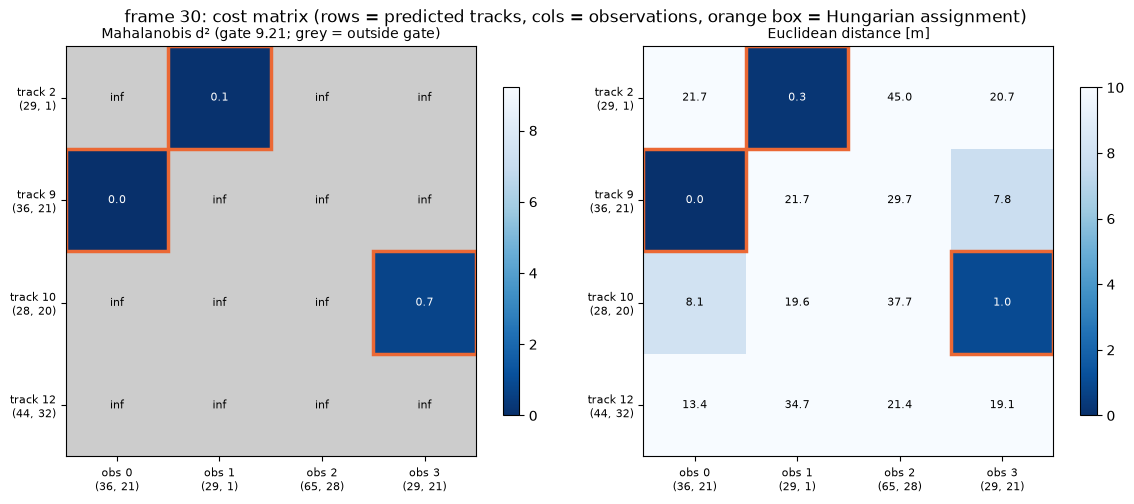

In [4]:
# 트랙 ≥ 3, 관측 ≥ 3 인 첫 프레임(30 이후) 을 예시로
F = next(f for f in FRAMES if f >= 30 and len(snapshots[f]["track_ids"]) >= 3 and len(snapshots[f]["obs"]) >= 3)
s = snapshots[F]
T, D = s["cost"].shape
eucl = np.linalg.norm(np.array(s["pred"])[:, None, :] - s["obs"][None, :, :], axis=2)
print(f"frame {F}: 트랙 {T}개 × 관측 {D}개, 할당 {s['matches']}, 미매칭 트랙 {[s['track_ids'][i] for i in range(T) if i not in [m[0] for m in s['matches']]]}")
fig, axes = plt.subplots(1, 2, figsize=(12, 0.6 * T + 2.5))
for ax, M, title, vmax in [(axes[0], s["cost"], f"Mahalanobis d² (gate {tracker.gate_mahalanobis}; grey = outside gate)", tracker.gate_mahalanobis),
                           (axes[1], eucl, "Euclidean distance [m]", 10)]:
    Mshow = np.where(np.isfinite(M), M, np.nan)
    im = ax.imshow(Mshow, cmap="Blues_r", vmin=0, vmax=vmax)
    ax.set_facecolor("0.8")
    for i in range(T):
        for j in range(D):
            txt = "inf" if not np.isfinite(M[i, j]) else f"{M[i, j]:.1f}"
            ax.text(j, i, txt, ha="center", va="center", fontsize=8, color="black" if (np.isfinite(M[i, j]) and M[i, j] > vmax * 0.5) else "white" if np.isfinite(M[i, j]) else "black")
    for (i, j) in s["matches"]:
        ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor="#eb6834", lw=2.5))
    ax.set_xticks(range(D), [f"obs {j}\n({s['obs'][j, 0]:.0f}, {s['obs'][j, 1]:.0f})" for j in range(D)], fontsize=8)
    ax.set_yticks(range(T), [f"track {tid}\n({p[0]:.0f}, {p[1]:.0f})" for tid, p in zip(s["track_ids"], s["pred"])], fontsize=8)
    ax.set_title(title, fontsize=10)
    fig.colorbar(im, ax=ax, shrink=0.8)
fig.suptitle(f"frame {F}: cost matrix (rows = predicted tracks, cols = observations, orange box = Hungarian assignment)")
fig.tight_layout(); plt.show()

읽는 법: 주황 테두리가 헝가리안이 고른 1:1 쌍. 같은 열에 두 트랙이 모두 게이트 안이면 총비용이 최소가 되도록 배정된다. 관측이 트랙보다 많으면 남는 관측은 **새 트랙**, 트랙이 남으면 **misses += 1**.

## 6.4 트랙 생명주기 표 — 생성 → 확정 → 삭제

`min_hits` = 3 이므로 트랙은 3번 매칭돼야 confirmed 가 되고 그때부터 출력에 나온다. `max_misses` = 3 이므로 4 프레임 연속 놓치면 삭제된다.

In [5]:
life = []
for tid, g in log.groupby("track_id"):
    g = g.sort_values("frame")
    conf = g[g.confirmed]
    life.append({"track_id": tid, "born": int(g.frame.min()), "confirmed_at": int(conf.frame.min()) if len(conf) else None,
                 "last_alive": int(g.frame.max()), "deleted_at": int(g.frame.max()) + 1 if g.frame.max() < FRAMES[-1] else None,
                 "frames_alive": len(g), "hits": int(g.hits.max()), "max_misses": int(g.misses.max()),
                 "coasting_frames": int((g.misses > 0).sum()), "x_at_birth": round(float(g.x.iloc[0]), 1), "y_at_birth": round(float(g.y.iloc[0]), 1)})
life = pd.DataFrame(life)
print(f"트랙 {len(life)}개 생성, 확정 {life.confirmed_at.notna().sum()}개, 확정 못 하고 삭제 {(life.confirmed_at.isna() & life.deleted_at.notna()).sum()}개 (오검출 또는 2 프레임 이하 깜빡임)")
life

트랙 29개 생성, 확정 13개, 확정 못 하고 삭제 14개 (오검출 또는 2 프레임 이하 깜빡임)


,track_id,born,confirmed_at,last_alive,deleted_at,frames_alive,hits,max_misses,coasting_frames,x_at_birth,y_at_birth
0,1,0,2.0,16,17.0,17,14,3,3,46.9,21.8
1,2,0,2.0,60,NaN,61,61,0,0,34.7,1.0
2,3,0,2.0,22,23.0,23,20,3,3,58.1,22.1
3,4,1,3.0,19,20.0,19,16,3,3,54.8,23.7
4,5,1,NaN,5,6.0,5,2,3,3,69.7,23.1
5,6,2,NaN,5,6.0,4,1,3,3,29.0,21.0
6,7,7,NaN,10,11.0,4,1,3,3,35.0,20.6
7,8,8,NaN,11,12.0,4,1,3,3,57.3,22.3
8,9,14,17.0,41,42.0,28,23,3,5,64.0,22.1
9,10,23,27.0,33,34.0,11,5,3,6,40.8,23.8


- `confirmed_at − born` 이 2 인 트랙이 정상 (3 프레임 연속 매칭). 그보다 크면 중간에 놓친 것.
- `confirmed_at` 이 None 인 트랙은 tentative 상태에서 죽은 것 → 출력에 한 번도 안 나왔다 (그래서 C 의 재현율이 초반에 낮다는 Phase 8 의 무효 비교 3번).
- 먼 곳(x_at_birth 40 m 이상)에서 태어난 트랙일수록 `coasting_frames` 가 많다: 점이 적어 융합이 `sparse`/`no_cluster` 로 빠지기 때문.

## 6.5 미검출 구간에서 coasting 하는 트랙

관측이 없는 프레임(misses > 0)에는 예측값만으로 위치가 갱신되고 공분산은 매 프레임 Q 만큼 커진다. coasting 프레임이 가장 많은 트랙을 골라 x 좌표와 위치 분산 P₀₀ 을 그린다.

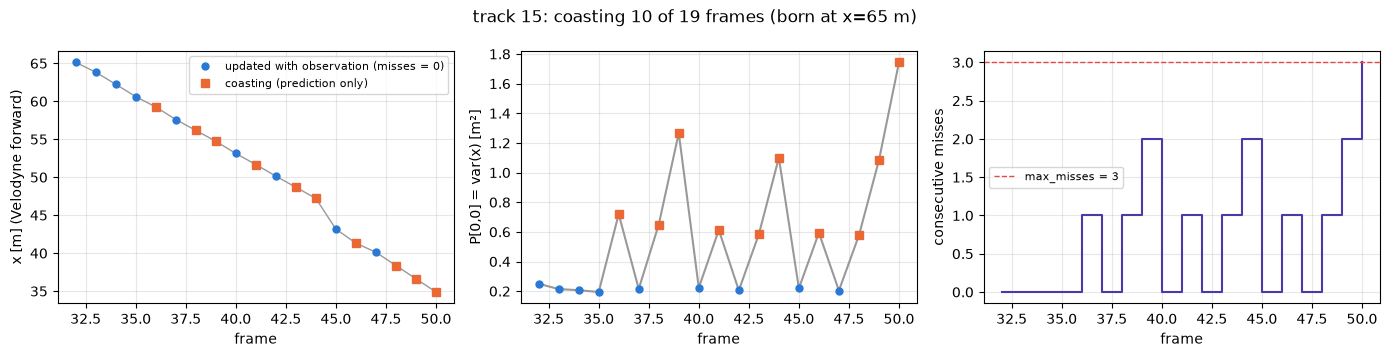

coasting 프레임: [36, 38, 39, 41, 43, 44, 46, 48, 49, 50]
한 프레임 coasting 시 var(x) 증가분 ≈ dt²·var(vx) + σp² =  0.334 m² (var(vx) 중앙값 8.39 기준)


In [6]:
tid = int(life.sort_values("coasting_frames", ascending=False).track_id.iloc[0])
g = log[log.track_id == tid].sort_values("frame")
obs_f, coast_f = g[g.misses == 0], g[g.misses > 0]
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
axes[0].plot(g.frame, g.x, "-", color="0.6", lw=1)
axes[0].plot(obs_f.frame, obs_f.x, "o", color="#2a78d6", ms=5, label="updated with observation (misses = 0)")
axes[0].plot(coast_f.frame, coast_f.x, "s", color="#eb6834", ms=6, label="coasting (prediction only)")
axes[0].set_xlabel("frame"); axes[0].set_ylabel("x [m] (Velodyne forward)"); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[1].plot(g.frame, g.P0, "-", color="0.6"); axes[1].plot(obs_f.frame, obs_f.P0, "o", color="#2a78d6", ms=5); axes[1].plot(coast_f.frame, coast_f.P0, "s", color="#eb6834", ms=6)
axes[1].set_xlabel("frame"); axes[1].set_ylabel("P[0,0] = var(x) [m²]"); axes[1].grid(alpha=0.3)
axes[2].plot(g.frame, g.misses, drawstyle="steps-post", color="#4a3aa7"); axes[2].axhline(tcfg["max_misses"], color="#e34948", ls="--", lw=1, label=f"max_misses = {tcfg['max_misses']}")
axes[2].set_xlabel("frame"); axes[2].set_ylabel("consecutive misses"); axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)
fig.suptitle(f"track {tid}: coasting {len(coast_f)} of {len(g)} frames (born at x={g.x.iloc[0]:.0f} m)"); fig.tight_layout(); plt.show()
print(f"coasting 프레임: {coast_f.frame.tolist()}")
print("한 프레임 coasting 시 var(x) 증가분 ≈ dt²·var(vx) + σp² = ", f"{tcfg['dt']**2 * g.P3.median() + tcfg['process_noise_pos']**2:.3f} m² (var(vx) 중앙값 {g.P3.median():.2f} 기준)")

관측이 들어오면 분산이 뚝 떨어지고(갱신), 없으면 계단처럼 커진다(예측). 분산이 커지면 마할라노비스 게이트가 **넓어져** 다시 나타난 관측을 잡기 쉬워진다 — coasting 이 짧은 가림을 견디는 원리.
반대로 너무 오래 coasting 하면 등속 가정이 틀려 위치가 밀리고, 그 자리에 다른 물체가 오면 잘못 잡는다.

## 6.6 ID 스위치 사례 — 좌측 차선 원거리 주차 차량 (gt3)

Phase 8 간트차트(`outputs/phase8/plots/05_track_gantt.png`)에서 gt3 (Car, 프레임 29~61) 은 트랙 15 → (공백) → 23/24 교대로 붙는다. 프레임 0~60 안에서 재현해 원인을 본다.
GT 는 tracklet 좌표(Velodyne, 바닥중심 + h/2) 를 그대로 쓴다.

In [7]:
GT_ID = 3
gt3 = {f: b for f in FRAMES for b in gts.get(f, []) if b.tracklet_id == GT_ID}
gt_traj = np.array([gt3[f].center for f in sorted(gt3)])
# 이 GT 에 2 m 안으로 접근한 트랙들
near = log[[np.linalg.norm([r.x - gt3[r.frame].center[0], r.y - gt3[r.frame].center[1]]) < 2.0 if r.frame in gt3 else False for r in log.itertuples()]]
ids = [int(t) for t in sorted(near.track_id.unique())]
print(f"gt{GT_ID} 프레임 {min(gt3)}~{max(gt3)}, 거리 {np.hypot(*gt_traj[0, :2]):.0f} → {np.hypot(*gt_traj[-1, :2]):.0f} m. 2 m 안에 들어온 트랙: {ids}")
print(near.groupby("track_id").frame.apply(lambda s: f"{s.min()}~{s.max()} ({len(s)}프레임)").to_string())

# 같은 구간의 융합 객체 상태: gt3 중심에서 3 m 안의 검출이 프레임마다 ok 였나?
print("\n프레임별 gt3 근처(3 m) 융합 객체 status / n_points:")
for f in range(44, 62):
    if f not in gt3: continue
    c = gt3[f].center
    cand = [o for o in objects[f] if o.center is not None and np.linalg.norm(o.center[:2] - c[:2]) < 3.0] + \
           [o for o in objects[f] if o.center is None]      # center 없는 실패 객체는 위치를 모르니 따로 표시
    print(f"  f{f}: gt=({c[0]:.1f},{c[1]:.1f}) ", ", ".join(f"{o.status}{'('+o.reason+')' if o.reason else ''}[{o.n_points}pt]" for o in cand) or "(검출 없음)")

gt3 프레임 28~60, 거리 75 → 34 m. 2 m 안에 들어온 트랙: [15, 21, 23, 24]
track_id
15    32~44 (13프레임)
21     49~51 (3프레임)
23     54~60 (7프레임)
24     57~58 (2프레임)

프레임별 gt3 근처(3 m) 융합 객체 status / n_points:
  f44: gt=(47.6,22.2)  sparse(3<5_points)[3pt], empty(no_points_after_filters)[0pt]
  f45: gt=(46.2,22.2)  invalid(no_cluster)[9pt], sparse(1<5_points)[1pt]
  f46: gt=(44.8,22.1)  empty(no_points_after_filters)[0pt]
  f47: gt=(43.5,22.0)  invalid(no_cluster)[16pt], empty(no_points_after_filters)[0pt]
  f48: gt=(42.1,22.0)  invalid(no_cluster)[5pt], empty(no_points_after_filters)[0pt]
  f49: gt=(40.6,21.9)  ok[10pt], invalid(no_cluster)[7pt], empty(no_points_after_filters)[0pt]
  f50: gt=(39.2,21.9)  ok[15pt], empty(no_points_after_filters)[0pt]
  f51: gt=(37.9,21.8)  empty(no_points_after_filters)[0pt]
  f52: gt=(36.6,21.8)  empty(no_points_after_filters)[0pt], invalid(no_cluster)[6pt]
  f53: gt=(35.3,21.7)  invalid(no_cluster)[6pt], empty(no_points_after_filters)[0pt]
  f54: gt=(34.0,21.7)  ok[1

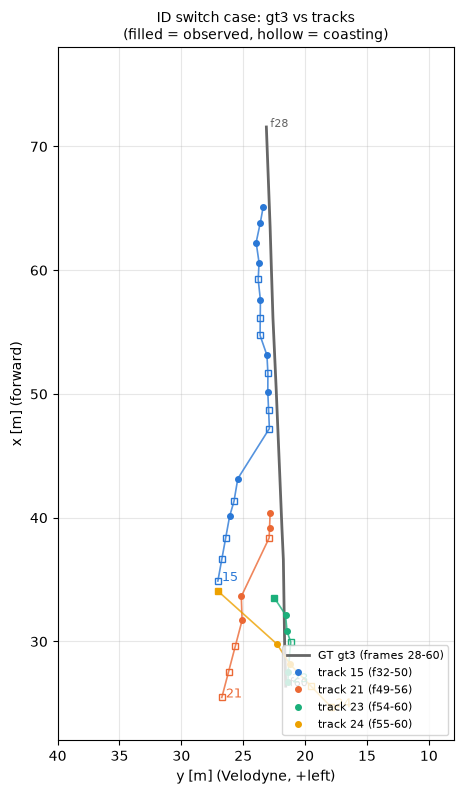

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 9))
ax.plot(gt_traj[:, 1], gt_traj[:, 0], "-", color="0.4", lw=2, label=f"GT gt{GT_ID} (frames {min(gt3)}-{max(gt3)})")
ax.text(gt_traj[0, 1], gt_traj[0, 0], f" f{min(gt3)}", color="0.4", fontsize=8); ax.text(gt_traj[-1, 1], gt_traj[-1, 0], f" f{max(gt3)}", color="0.4", fontsize=8)
palette = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
for k, tid in enumerate(ids):
    g = log[log.track_id == tid].sort_values("frame")
    ax.plot(g.y, g.x, "-", color=palette[k % 5], lw=1.2, alpha=0.8)
    ax.plot(g[g.misses == 0].y, g[g.misses == 0].x, "o", color=palette[k % 5], ms=4, label=f"track {tid} (f{g.frame.min()}-{g.frame.max()})")
    ax.plot(g[g.misses > 0].y, g[g.misses > 0].x, "s", mfc="none", color=palette[k % 5], ms=5)
    ax.text(g.y.iloc[-1], g.x.iloc[-1], f" {tid}", color=palette[k % 5], fontsize=9)
ax.set_xlim(40, 8); ax.set_ylim(22, 78); ax.set_aspect("equal"); ax.grid(alpha=0.3)      # +y(좌) 가 왼쪽에 오도록 x 축 뒤집음
ax.set_xlabel("y [m] (Velodyne, +left)"); ax.set_ylabel("x [m] (forward)")
ax.set_title(f"ID switch case: gt{GT_ID} vs tracks\n(filled = observed, hollow = coasting)", fontsize=10)
ax.legend(fontsize=8, loc="lower right"); plt.show()

**원인** (위 status 출력과 궤적으로 확인):
1. gt3 은 왼쪽 차선에 주차된 차로, 자차가 다가가면서 40 m 대에서 20 m 대로 들어온다. 먼 구간에서는 LiDAR 점이 5~15개뿐이라 융합이 `sparse` / `no_cluster` 로 자주 실패한다 → 관측이 깜빡인다.
2. 트랙 15 는 깜빡임을 coasting 으로 버티다가 4 프레임 연속 놓치자(`max_misses` = 3) 삭제된다.
3. 프레임 49~50 에 잠깐 `ok` 관측이 돌아와 트랙 21 이 생기지만 51~53 이 다시 비어 **확정(min_hits = 3) 도 못 하고** 죽는다 (출력에 한 번도 안 나옴).
4. 30 m 안으로 들어와 검출이 안정되면(54~) 트랙 23 이 태어나 확정되는데, 프레임 57 에 같은 차에서 `ok` 객체가 **2개** (18점, 25점 — 클러스터가 둘로 갈라짐, 1 m 넘게 떨어져 `dedup` 을 통과) 나와 트랙 24 가 추가로 생긴다. 이후 두 트랙이 GT 에 번갈아 매칭된다 → IDSW.

즉 이 ID 스위치는 칼만 필터의 잘못이 아니라 (a) 먼 물체의 관측 결손과 (b) 융합의 중복 객체가 원인이다. 대책: `max_misses` 를 늘려 더 오래 버티기(유령 FP 증가와 트레이드오프), 융합의 `dedup_distance_m` 조정, 또는 외형(2D 박스 IoU)을 비용에 추가.

## 6.7 파라미터 스윕 — `measurement_noise` × `max_misses`

전 297 프레임을 돌려(추적은 프레임당 0.3 ms) Phase 8 평가 함수로 IDSW·단절·재현율·정밀도를 비교한다. 매칭 임계값 2 m, GT 필터는 results.md 와 동일.

In [9]:
def run_tracker(cfg_over: dict) -> dict:
    c = copy.deepcopy(cfg); c["tracking"].update(cfg_over)
    tr = KalmanTracker(c); out = {}
    for f in sorted(objects):
        out[f] = [t.as_dict(f) for t in tr.step(objects[f], f)]
    return out

sweep = []
for mn in (0.25, 0.5, 1.0):
    for mm in (2, 3, 5):
        r = evaluate_variant(run_tracker({"measurement_noise": mn, "max_misses": mm}), gts, cfg, f"mn{mn}_mm{mm}")
        o, t = r["overall"], r["tracking"]
        sweep.append({"measurement_noise": mn, "max_misses": mm, "IDSW": t["idsw"], "frag": t["frag"], "track_ids": t["n_track_ids"],
                      "MT": t["mt"], "ML": t["ml"], "recall": round(o["recall"], 3), "precision": round(o["precision"], 3), "MOTA": round(o["mota"], 3),
                      "BEV_median": round(o["bev_median"], 2), "coasting_pred": t["n_coasting_pred"]})
sweep = pd.DataFrame(sweep)
print("기본값 (0.5, 3) 행이 outputs/phase8/results.md 의 C 와 같아야 한다.")
sweep

기본값 (0.5, 3) 행이 outputs/phase8/results.md 의 C 와 같아야 한다.


,measurement_noise,max_misses,IDSW,frag,track_ids,MT,ML,recall,precision,MOTA,BEV_median,coasting_pred
0,0.25,2,12,11,52,13,4,0.641,0.843,0.513,0.56,158
1,0.25,3,10,12,53,13,4,0.649,0.797,0.476,0.56,224
2,0.25,5,8,11,56,13,4,0.656,0.713,0.386,0.56,368
3,0.50,2,10,10,51,13,4,0.640,0.824,0.496,0.55,158
4,0.50,3,9,11,53,13,4,0.647,0.780,0.458,0.56,225
5,0.50,5,12,11,60,13,4,0.654,0.681,0.339,0.56,397
6,1.00,2,14,12,49,11,4,0.650,0.827,0.504,0.57,156
7,1.00,3,10,11,50,12,4,0.656,0.790,0.474,0.57,213
8,1.00,5,8,12,54,13,4,0.661,0.707,0.382,0.58,348


읽는 법
- `max_misses` 2 → 5: coasting 예측이 158 → 350~400 으로 늘어 재현율은 +1 %p 정도만 오르고 정밀도는 0.82~0.84 → 0.68~0.71 로 크게 떨어진다 (유령 트랙). MOTA 는 max_misses 2 가 가장 높다. IDSW 는 8~14 사이에서 오르내리며 **단조 경향이 없다** — 오래 버티면 재생성이 줄어 IDSW 가 주는 경우(0.25, 1.0)와, 밀려난 coasting 트랙이 이웃 물체를 잡아 IDSW 가 느는 경우(0.5) 가 섞인다.
- `measurement_noise` 0.25 → 1.0: 게이트 S = HP⁻Hᵀ + R 이 넓어지고 갱신이 느려지는데, 이 시퀀스에서는 재현율·정밀도·BEV 오차가 거의 안 변한다 (±1 %p). 즉 융합 중심 오차(≈0.5 m)에 대해 R 은 민감한 파라미터가 아니다. IDSW 도 뚜렷한 경향이 없다 (팀 E 의 스윕과 같은 결론: 기본 0.5 유지).
- MT/ML 은 어느 조합에서도 13/4 근처: 먼 물체(ML 4개 = gt4, gt10, gt32, gt34 Cyclist) 는 관측 자체가 없어 추적 파라미터로 구제할 수 없다.
- 이 표는 **한 시퀀스(297 프레임, 36 tracklet)** 결과다. IDSW 는 총 10건 안팎이라 ±2 는 잡음 수준이며, 다른 장면(교차로, 보행자 많음)에서는 최적이 다를 수 있다.

## 6.8 프레임 이미지 위 트랙 ID + BEV 궤적 (프레임 0~60)

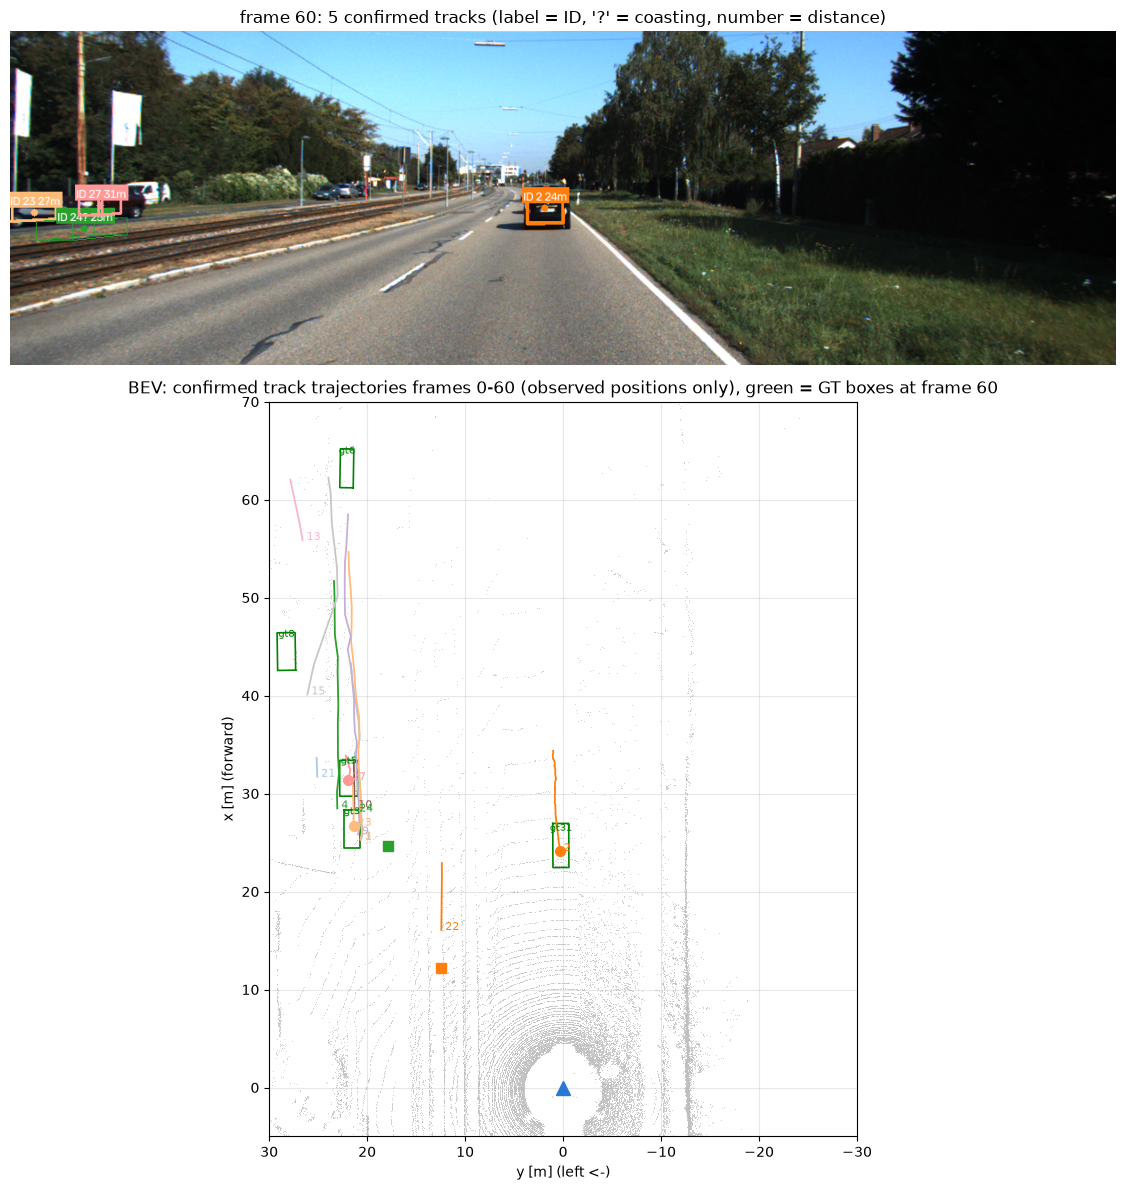

In [10]:
F_SHOW = 60
fr = ds.load_frame(F_SHOW)
tracker_show = KalmanTracker(cfg)
for f in range(0, F_SHOW + 1):
    tracks_now = tracker_show.step([o for o in objects[f] if o.status == "ok"], f)
img = draw_tracks_on_image(fr["image"], tracks_now, calib)
gt_now = select_gt(gts.get(F_SHOW, []), cfg["fusion"]["roi"]["x_max"], cfg["evaluation"]["classes"])

fig = plt.figure(figsize=(14, 12)); gs = fig.add_gridspec(2, 1, height_ratios=[1, 2.2])
ax0 = fig.add_subplot(gs[0]); ax0.imshow(img[:, :, ::-1]); ax0.set_axis_off()
ax0.set_title(f"frame {F_SHOW}: {len(tracks_now)} confirmed tracks (label = ID, '?' = coasting, number = distance)")
ax1 = fig.add_subplot(gs[1])
pts = fr["points"]; sub = pts[np.random.default_rng(0).choice(len(pts), 40000, replace=False)]
ax1.scatter(sub[:, 1], sub[:, 0], s=0.3, c="0.75", linewidths=0, rasterized=True)
for b in gt_now:
    c = box_corners_bev(b.center, b.size, b.yaw); c = np.vstack([c, c[:1]])
    ax1.plot(c[:, 1], c[:, 0], color="#008300", lw=1.2); ax1.text(b.center[1], b.center[0] + 1.5, f"gt{b.tracklet_id}", color="#008300", fontsize=7, ha="center")
cmap = plt.get_cmap("tab20")
for tid, g in log[log.confirmed].groupby("track_id"):
    g = g[g.misses == 0].sort_values("frame")
    ax1.plot(g.y, g.x, "-", color=cmap(tid % 20), lw=1.3)
    ax1.text(g.y.iloc[-1], g.x.iloc[-1], f" {tid}", color=cmap(tid % 20), fontsize=8)
for t in tracks_now:
    ax1.plot(t.position[1], t.position[0], "o" if t.misses == 0 else "s", color=cmap(t.track_id % 20), ms=7)
ax1.plot(0, 0, "^", color="#2a78d6", ms=10); ax1.set_xlim(30, -30); ax1.set_ylim(-5, 70); ax1.set_aspect("equal"); ax1.grid(alpha=0.3)
ax1.set_xlabel("y [m] (left <-)"); ax1.set_ylabel("x [m] (forward)")
ax1.set_title(f"BEV: confirmed track trajectories frames 0-{F_SHOW} (observed positions only), green = GT boxes at frame {F_SHOW}")
fig.tight_layout(); fig.savefig(f"{cfg['outputs']['dir']}/phase8/nb06_frame{F_SHOW}_tracks.png", dpi=100); plt.show()

관찰: 자차 앞 같은 차선의 차(gt31, 트랙 2)는 60 프레임 내내 한 ID 를 유지한다. 반면 왼쪽 차선의 주차 차량들은 자차 기준 −10 m/s 대로 "다가오며" 짧게 보이고, 먼 구간에서 깜빡여 ID 가 잘게 끊긴다.

## 6.9 자가 점검 질문

1. 관측이 없는 프레임에서 `P[0,0]` 이 얼마나 커지는지 Q 와 F 로 식을 써 보라. 6.5 의 계단 높이와 맞는가? (힌트: P⁻ = F P Fᵀ + Q 의 (0,0) 성분 = P₀₀ + 2·dt·P₀₃ + dt²·P₃₃ + σp²)
2. 6.3 의 비용 행렬에서 어떤 트랙이 유클리드로는 가장 가까운 관측을 두고 다른 관측에 배정되었다면, 마할라노비스 거리에서 그 이유는 무엇인가? (S 의 크기, 게이트, 헝가리안의 총비용 최소화 중 무엇이 작용했나)
3. `min_hits` 를 1 로 낮추면 C 의 재현율·정밀도·IDSW 는 각각 어느 방향으로 움직일지 예측하고, 6.7 의 `run_tracker` 로 확인해 보라. 결과가 예측과 다르면 어떤 가정이 틀렸는가?